In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, LeakyReLU, Dropout, Flatten, Dense
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import cv2
import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

In [2]:
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


In [3]:
# Define input folders
mountain_folder = "/content/gdrive/MyDrive/mountain"
sand_folder = "/content/gdrive/MyDrive/sand"
river_folder = "/content/gdrive/MyDrive/River"  # Add the path to the River folder

In [4]:
# Function to load and preprocess images
def loadImages(folder):
    imgList = []
    dim = (128, 128)
    for img in glob.glob(folder + "/*.jpg"):
        n = cv2.imread(img)
        resized = cv2.resize(n, dim, interpolation=cv2.INTER_AREA)
        normalized_img = resized.astype(np.float32) / 255.0
        imgList.append(normalized_img)

    npImg = np.asarray(imgList, dtype=np.float32)
    return npImg


In [5]:
# Load and preprocess mountain images
mountain_images = loadImages(mountain_folder)
mountain_labels = np.zeros(len(mountain_images))  # Assign label 0 for mountain class

# Load and preprocess sand images
sand_images = loadImages(sand_folder)
sand_labels = np.ones(len(sand_images))  # Assign label 1 for sand class

# Load and preprocess river images
river_images = loadImages(river_folder)
river_labels = np.full(len(river_images), 2)  # Assign label 2 for river class

In [6]:
# Concatenate the images and labels for all three classes
X = np.concatenate([mountain_images, sand_images, river_images], axis=0)
y = np.concatenate([mountain_labels, sand_labels, river_labels], axis=0)



# Split the data into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print("Train set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Train set shape: (1901, 128, 128, 3)
Validation set shape: (476, 128, 128, 3)
Test set shape: (265, 128, 128, 3)


In [15]:
# Create the classifier model
model = Sequential()

# Convolutional layer 1
model.add(Conv2D(64, kernel_size=(5, 5), strides=(2, 2), padding='same', input_shape=(128, 128, 3)))
model.add(LeakyReLU(alpha=0.2))
model.add(Dropout(0.25))

# Convolutional layer 2
model.add(Conv2D(128, kernel_size=(5, 5), strides=(2, 2), padding='same'))
model.add(LeakyReLU(alpha=0.2))
model.add(Dropout(0.25))

# Flatten the feature maps
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(3, activation='softmax'))  # Update the output units to 3 for 3 classes

# Print model summary
model.summary()

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])



Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 64, 64, 64)        4864      
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 64, 64, 64)        0         
                                                                 
 dropout_4 (Dropout)         (None, 64, 64, 64)        0         
                                                                 
 conv2d_5 (Conv2D)           (None, 32, 32, 128)       204928    
                                                                 
 leaky_re_lu_5 (LeakyReLU)   (None, 32, 32, 128)       0         
                                                                 
 dropout_5 (Dropout)         (None, 32, 32, 128)       0         
                                                                 
 flatten_2 (Flatten)         (None, 131072)           

In [16]:
# Train the model
history = model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_val, y_val), shuffle=True)

Epoch 1/20
60/60 [==============================] - 3s 38ms/step - loss: 0.6986 - accuracy: 0.7091 - val_loss: 0.1140 - val_accuracy: 0.9433
Epoch 2/20
60/60 [==============================] - 2s 33ms/step - loss: 0.4566 - accuracy: 0.8506 - val_loss: 0.0530 - val_accuracy: 0.9979
Epoch 3/20
60/60 [==============================] - 2s 34ms/step - loss: 0.2023 - accuracy: 0.9390 - val_loss: 0.2646 - val_accuracy: 0.8550
Epoch 4/20
60/60 [==============================] - 2s 35ms/step - loss: 0.1192 - accuracy: 0.9579 - val_loss: 0.0232 - val_accuracy: 0.9958
Epoch 5/20
60/60 [==============================] - 2s 33ms/step - loss: 0.0142 - accuracy: 0.9979 - val_loss: 0.0153 - val_accuracy: 0.9937
Epoch 6/20
60/60 [==============================] - 2s 33ms/step - loss: 0.0076 - accuracy: 0.9984 - val_loss: 0.0056 - val_accuracy: 1.0000
Epoch 7/20
60/60 [==============================] - 2s 31ms/step - loss: 0.0101 - accuracy: 0.9979 - val_loss: 0.0097 - val_accuracy: 0.9979
Epoch 8/20
60

9/9 [==============================] - 0s 14ms/step - loss: 1.5005e-04 - accuracy: 1.0000
Test Loss: 0.00015004856686573476
Test Accuracy: 1.0


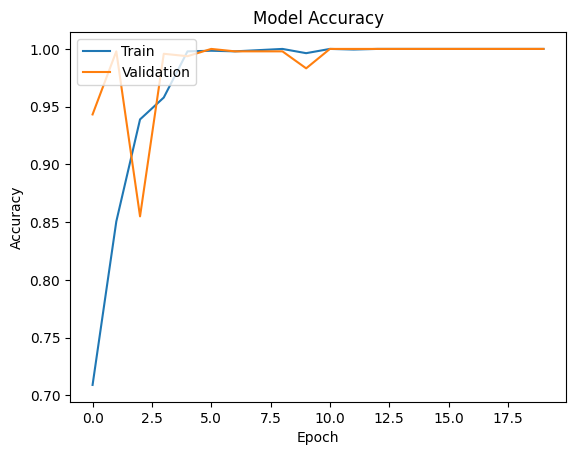

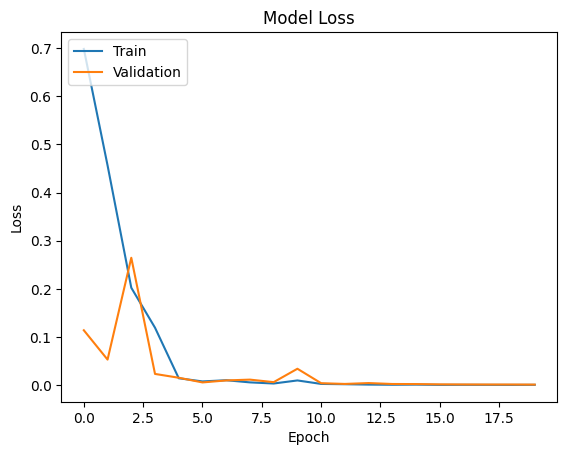

In [17]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Plot accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [13]:
# Perform predictions on test images
predictions = model.predict(X_test)

# Map class indices to class labels
class_labels = ['mountain', 'sand', 'river']  # Add 'river' to the class labels

# Get the predicted class for each image
predicted_classes = np.argmax(predictions, axis=1)

# Get the true class for each image
true_labels = [class_labels[int(label)] for label in y_test]

# Select a specific number of images to test
num_images_to_test = 10  # Replace with the desired number of images to test
indices_to_test = np.random.choice(len(predicted_classes), num_images_to_test, replace=False)

# Print predicted and true labels for the selected images
for i in indices_to_test:
    print('Predicted:', class_labels[predicted_classes[i]], 'True:', true_labels[i])


9/9 [==============================] - 0s 13ms/step
Predicted: sand True: sand
Predicted: sand True: sand
Predicted: mountain True: mountain
Predicted: mountain True: mountain
Predicted: mountain True: mountain
Predicted: mountain True: mountain
Predicted: mountain True: mountain
Predicted: river True: river
Predicted: river True: river
Predicted: sand True: sand


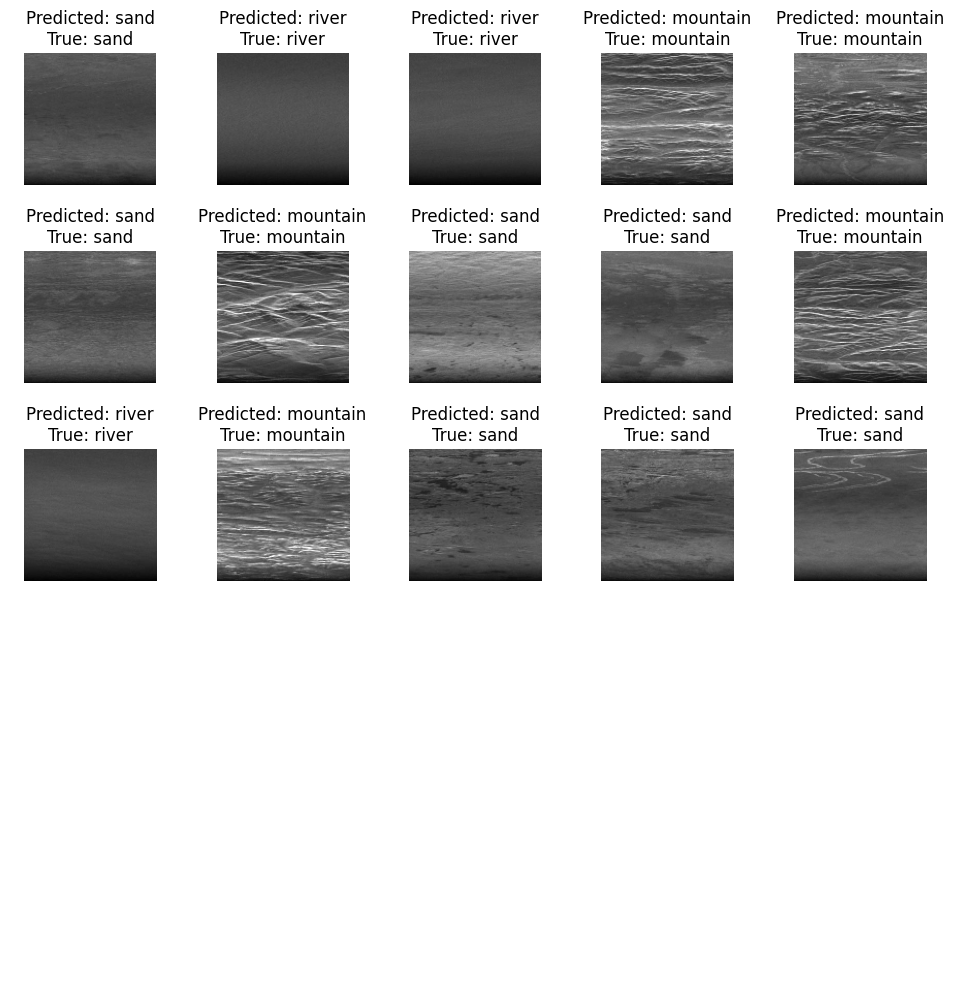

In [22]:
import matplotlib.pyplot as plt

# Select a larger number of images to visualize
num_images_to_visualize = 15 # Replace with the desired number of images to visualize

# Create a grid of images and labels
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(12, 12))
fig.subplots_adjust(hspace=0.5)

for i, ax in enumerate(axes.flat):
    if i < num_images_to_visualize:
        # Display the image
        ax.imshow(X_test[i])
        ax.axis('off')

        # Display the predicted and true labels
        ax.set_title(f"Predicted: {class_labels[predicted_classes[i]]}\nTrue: {true_labels[i]}")
    else:
        ax.axis('off')

plt.show()


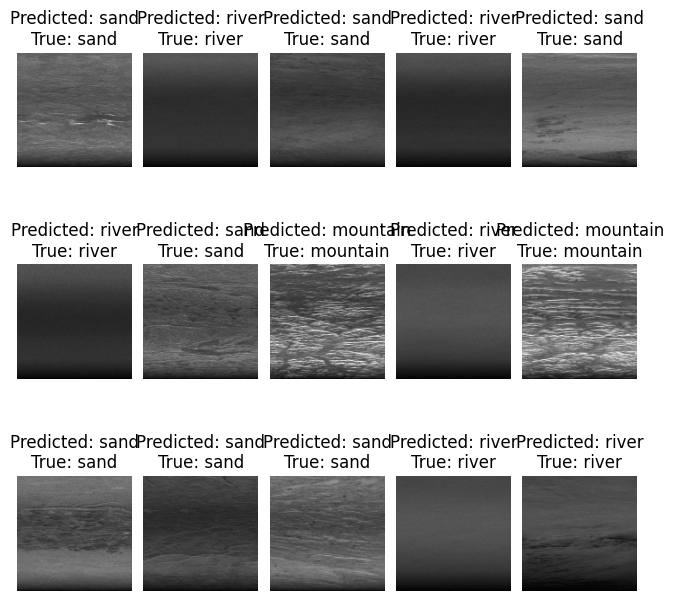

In [29]:
import matplotlib.pyplot as plt
import random  # Import the random module

# Shuffle the indices of the test set to randomize the selection
shuffled_indices = list(range(len(X_test)))
random.shuffle(shuffled_indices)

# Select a larger number of images to visualize
num_images_to_visualize = 15  # Replace with the desired number of images to visualize

# Create a grid of images and labels with reduced spacing
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(8, 8))  # Adjust the figsize as needed
fig.subplots_adjust(hspace=0.1, wspace=0.1)  # Decrease the spacing

for i, ax in enumerate(axes.flat):
    if i < num_images_to_visualize:
        # Get the index of the image to display
        index_to_display = shuffled_indices[i]

        # Display the image
        ax.imshow(X_test[index_to_display])
        ax.axis('off')

        # Display the predicted and true labels
        ax.set_title(f"Predicted: {class_labels[predicted_classes[index_to_display]]}\nTrue: {true_labels[index_to_display]}")
    else:
        ax.axis('off')

plt.show()


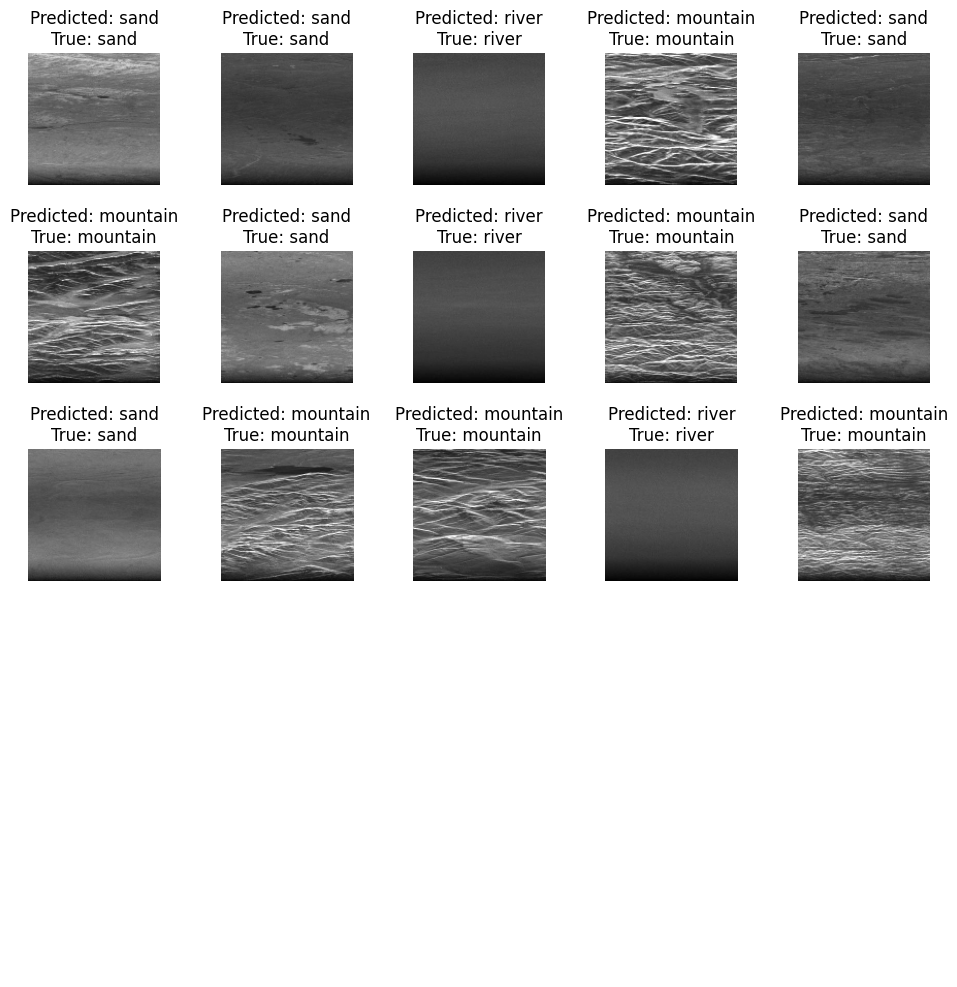

In [28]:
import matplotlib.pyplot as plt
import random  # Import the random module

# Shuffle the indices of the test set to randomize the selection
shuffled_indices = list(range(len(X_test)))
random.shuffle(shuffled_indices)

# Select a larger number of images to visualize
num_images_to_visualize = 15  # Replace with the desired number of images to visualize

# Create a grid of images and labels
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(12, 12))
fig.subplots_adjust(hspace=0.5)

for i, ax in enumerate(axes.flat):
    if i < num_images_to_visualize:
        # Get the index of the image to display
        index_to_display = shuffled_indices[i]

        # Display the image
        ax.imshow(X_test[index_to_display])
        ax.axis('off')

        # Display the predicted and true labels
        ax.set_title(f"Predicted: {class_labels[predicted_classes[index_to_display]]}\nTrue: {true_labels[index_to_display]}")
    else:
        ax.axis('off')

plt.show()
